![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 9: Foundation Models

**Goal of this lab.** By the end, you should walk away knowing that a whole
*toolbox* of ready-to-use **foundation models** exists - and that for many
problems you can grab one off the shelf, run a few lines of code, and get
useful results **without training anything yourself**.


## Part 0 - The Hugging Face Hub: where the tools live

Almost every model in this lab comes from the [**Hugging Face Hub**](https://huggingface.co/models) -
a giant public library of pretrained models.

**You can search by task and modality.** Open
   [huggingface.co/models](https://huggingface.co/models) and use the left
   sidebar: *Computer Vision -> Object Detection*, *Multimodal -> Image-Text-to-Text*,
   *Tabular*, *Audio*, and so on. Each model has a **model card** with example code.

In [1]:
import torch, gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device :", device, "(<- want 'cuda' on a T4)")


def load_image(url):
    """Download an image and return a PIL RGB image."""
    resp = requests.get(url, timeout=30, headers={"User-Agent": "kaust-lab"})
    resp.raise_for_status()
    return Image.open(BytesIO(resp.content)).convert("RGB")


def free_memory(*objs):
    """Delete model objects and clear the GPU cache between sections."""
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Memory freed.")

PyTorch: 2.11.0+cu128
Device : cuda (<- want 'cuda' on a T4)


In [2]:
import requests
from io import BytesIO
from PIL import Image

def load_image(url):
    """Download an image and return a PIL RGB image. Fails loudly (no fake data)."""
    resp = requests.get(url, timeout=30, headers={"User-Agent": "kaust-lab"})
    resp.raise_for_status()
    return Image.open(BytesIO(resp.content)).convert("RGB")

# Sample image: two cats on a couch, from the COCO dataset (reliable URL).
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(IMAGE_URL)

## 1. CLIP - zero-shot classification (classify against *any* labels)

**What it's for.** CLIP was trained on 400M image-text pairs to place images and
text in the *same* embedding space. Practical payoff: to classify an image, you
just write your candidate labels **as sentences** and ask which one is closest.


In [4]:
from transformers import CLIPProcessor, CLIPModel

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# You invent the label set - try changing these!
labels = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of two cats resting",
    "a photo of a car",
    "a plate of food",
]

inputs = clip_proc(text=labels, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    probs = clip(**inputs).logits_per_image.softmax(dim=-1)[0]

print("CLIP's ranking (no training involved):\n")
for label, p in sorted(zip(labels, probs.tolist()), key=lambda x: -x[1]):
    bar = "#" * int(p * 30)
    print(f"{p:5.1%} |{bar:<30}| {label}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP's ranking (no training involved):

99.4% |############################# | a photo of two cats resting
 0.6% |                              | a photo of a cat
 0.0% |                              | a plate of food
 0.0% |                              | a photo of a dog
 0.0% |                              | a photo of a car


In [5]:
free_memory(clip, clip_proc)

Memory freed.


## 2. DINOv2

**What it's for.** DINOv2 is a self-supervised vision model trained on 142M images.
It never saw your labels, but its **frozen features** are so good that you can build
a classifier or a search engine on top of them with *no training*ز

We'll embed a slice of CIFAR-10, then (a) classify test images with a plain
**k-nearest-neighbours** lookup and (b) do **image retrieval** - find the gallery
images most similar to a query.


In [7]:
from transformers import AutoImageProcessor, AutoModel
from datasets import load_dataset

dino_proc = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dino = AutoModel.from_pretrained("facebook/dinov2-base").to(device).eval()

# CIFAR-10 from the HF Hub (reliable CDN) instead of the flaky torchvision mirror.
ds_train = load_dataset("uoft-cs/cifar10", split="train[:400]")
ds_test  = load_dataset("uoft-cs/cifar10", split="test[:200]")
class_names = ds_train.features["label"].names

# Match the old shape: a list of (PIL image, label) tuples.
gallery = [(ex["img"], ex["label"]) for ex in ds_train]
queries = [(ex["img"], ex["label"]) for ex in ds_test]
print(f"Gallery: {len(gallery)} images | Queries: {len(queries)} images")


@torch.no_grad()
def dino_embed(pil_images, batch=32):
    """Return one feature vector per image using DINOv2's pooled output."""
    feats = []
    for i in range(0, len(pil_images), batch):
        chunk = pil_images[i:i + batch]
        inp = dino_proc(images=chunk, return_tensors="pt").to(device)
        feats.append(dino(**inp).pooler_output.cpu())
    return torch.cat(feats).numpy()

gallery_feats = dino_embed([im for im, _ in gallery])
query_feats = dino_embed([im for im, _ in queries])
gallery_lbls = np.array([lb for _, lb in gallery])
query_lbls = np.array([lb for _, lb in queries])
print("Feature dimension:", gallery_feats.shape[1])

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Gallery: 400 images | Queries: 200 images
Feature dimension: 768


In [8]:
from sklearn.neighbors import KNeighborsClassifier

# (a) Classify with a simple kNN on frozen features
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(gallery_feats, gallery_lbls)
acc = knn.score(query_feats, query_lbls)
print(f"kNN on frozen DINOv2 features: {acc:.1%} accuracy on CIFAR-10 "
      f"(10 classes, chance = 10%).")

kNN on frozen DINOv2 features: 96.0% accuracy on CIFAR-10 (10 classes, chance = 10%).


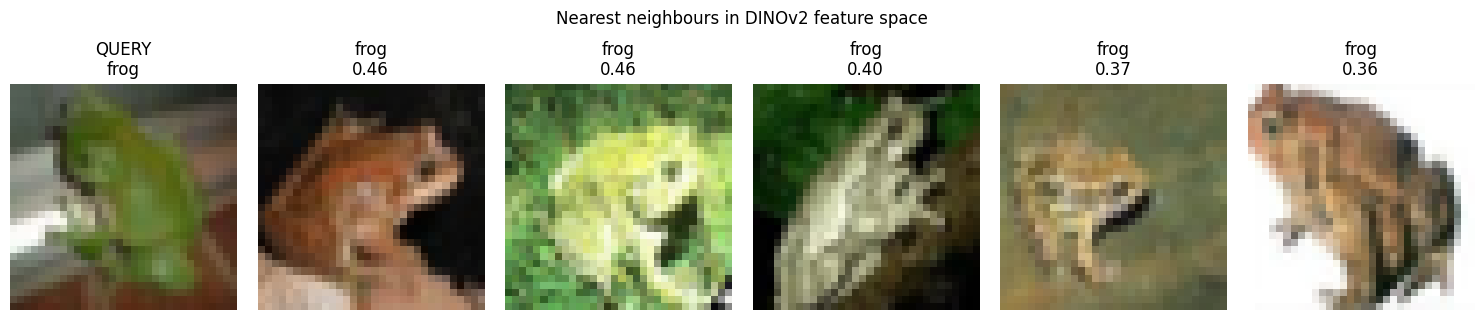

In [9]:
# (b) Retrieval: pick a query image, show the most similar gallery images.
def l2norm(x):
    return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-8)

g = l2norm(gallery_feats)
q = l2norm(query_feats)

qi = 7  # try other indices
sims = g @ q[qi]
top = sims.argsort()[::-1][:5]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(queries[qi][0]); axes[0].set_title(f"QUERY\n{class_names[query_lbls[qi]]}")
axes[0].axis("off")
for ax, idx in zip(axes[1:], top):
    ax.imshow(gallery[idx][0])
    ax.set_title(f"{class_names[gallery_lbls[idx]]}\n{sims[idx]:.2f}")
    ax.axis("off")
plt.suptitle("Nearest neighbours in DINOv2 feature space", y=1.05)
plt.tight_layout(); plt.show()

**What it buys you.** A strong classifier *and* a similarity search engine from
**frozen features + a few lines**.

**Where you'd use it in a project:**
- **Visual search / dedup:** "find images similar to this one" over a catalogue.
- **Clustering / discovery:** group an unlabeled image dump before you annotate.
- **Few-shot classification:** kNN on features when you have very little labeled data.
- **Powerful Backbone:** You can finetune / add a head on your own data.

In [11]:
free_memory(dino, dino_proc)

Memory freed.


## Auto-labeling: text prompt -> boxes -> masks

Manually drawing segmentation masks is the most
tedious job in computer vision. Here we **chain two foundation models** to do it
from a text prompt:

1. **Grounding DINO** - open-vocabulary *detection*. Give it a phrase like
   `"a cat. a remote control."` and it returns **boxes** for those things.
2. **SAM (Segment Anything)** - promptable *segmentation*. Feed it those boxes
   and it returns pixel-perfect **masks**.


In [12]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

GD_ID = "IDEA-Research/grounding-dino-base"
gd_proc = AutoProcessor.from_pretrained(GD_ID)
gd_model = AutoModelForZeroShotObjectDetection.from_pretrained(GD_ID).to(device)

# Grounding DINO wants lowercase phrases, each ending in a period.
TEXT_PROMPT = "a cat. a remote control."

gd_inputs = gd_proc(images=image, text=TEXT_PROMPT, return_tensors="pt").to(device)
with torch.no_grad():
    gd_outputs = gd_model(**gd_inputs)

results = gd_proc.post_process_grounded_object_detection(
    gd_outputs,
    gd_inputs["input_ids"],
    threshold=0.35,
    target_sizes=[image.size[::-1]],  # (height, width)
)[0]

boxes = results["boxes"]                                   # xyxy pixel boxes
phrases = results.get("text_labels", results.get("labels"))
scores = results["scores"]

print(f"Grounding DINO found {len(boxes)} objects for prompt: {TEXT_PROMPT!r}\n")
for box, phrase, score in zip(boxes.tolist(), phrases, scores.tolist()):
    xy = [round(v, 1) for v in box]
    print(f"  {score:.0%}  {phrase:<16} box={xy}")

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

Grounding DINO found 3 objects for prompt: 'a cat. a remote control.'

  44%  a cat            box=[347.2, 22.2, 635.7, 375.0]
  48%  a cat            box=[9.9, 51.3, 318.5, 472.7]
  47%  a remote control box=[38.0, 71.2, 176.5, 117.9]


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


In [13]:
from transformers import SamModel, SamProcessor

sam = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
sam_proc = SamProcessor.from_pretrained("facebook/sam-vit-base")

# Feed Grounding DINO's boxes to SAM as prompts -> one mask per box.
input_boxes = [boxes.tolist()]  # shape: [batch][num_boxes][4]
sam_inputs = sam_proc(image, input_boxes=input_boxes, return_tensors="pt").to(device)
with torch.no_grad():
    sam_outputs = sam(**sam_inputs)

masks = sam_proc.image_processor.post_process_masks(
    sam_outputs.pred_masks.cpu(),
    sam_inputs["original_sizes"].cpu(),
    sam_inputs["reshaped_input_sizes"].cpu(),
)[0]  # tensor: (num_boxes, num_masks_per_box, H, W)

iou = sam_outputs.iou_scores.cpu()[0]  # (num_boxes, num_masks_per_box)
best = iou.argmax(dim=-1)              # pick SAM's most confident mask per box
final_masks = [masks[i, best[i]].numpy() for i in range(masks.shape[0])]
print(f"SAM produced {len(final_masks)} masks - one per detected box.")

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

SAM produced 3 masks - one per detected box.


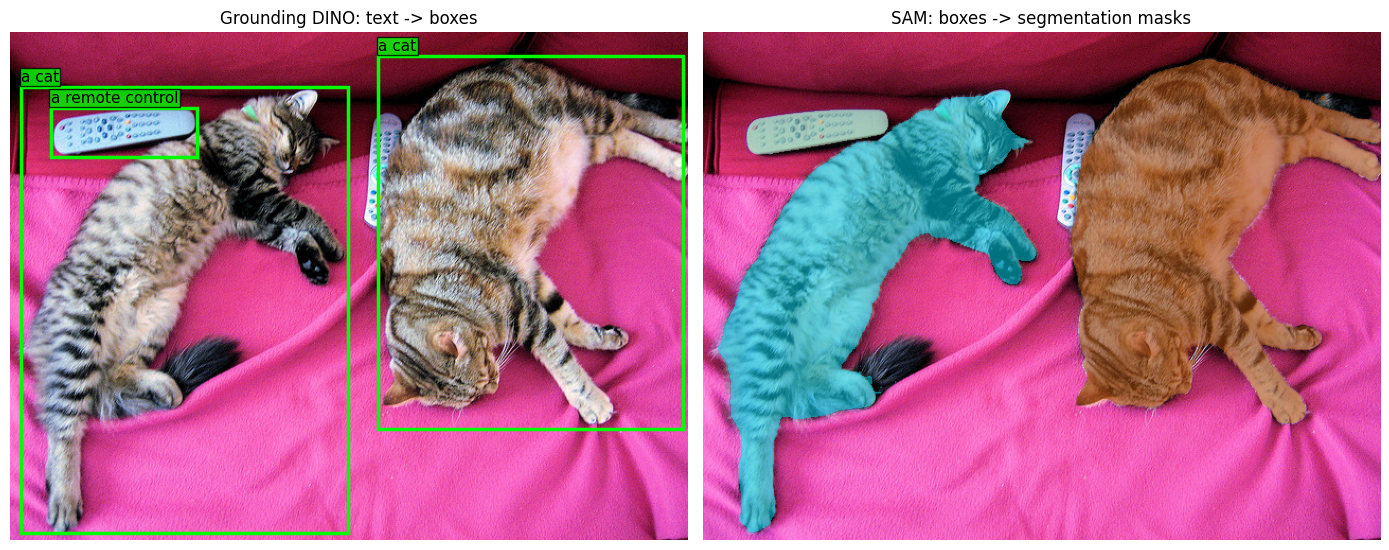

In [14]:
# Visualize: original + boxes, and the auto-generated masks overlaid.
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(image); ax1.set_title("Grounding DINO: text -> boxes"); ax1.axis("off")
for box, phrase in zip(boxes.tolist(), phrases):
    x0, y0, x1, y1 = box
    ax1.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                    fill=False, edgecolor="lime", linewidth=2.5))
    ax1.text(x0, y0 - 5, phrase, color="black", fontsize=11,
             bbox=dict(facecolor="lime", alpha=0.8, pad=1))

ax2.imshow(image); ax2.set_title("SAM: boxes -> segmentation masks"); ax2.axis("off")
rng = np.random.default_rng(0)
for m in final_masks:
    color = rng.random(3)
    overlay = np.zeros((*m.shape, 4))
    overlay[m > 0] = [*color, 0.55]
    ax2.imshow(overlay)

plt.tight_layout(); plt.show()

In [15]:
free_memory(gd_model, gd_proc, sam, sam_proc)

Memory freed.


## 3. YOLO-World - open-vocabulary detection, in *real time*

**What it's for.** Grounding DINO is powerful but heavy. **YOLO-World** gives you
the same "detect anything you can name" ability at **real-time speed** - fast enough
for video and webcams. You hand it a list of class names and it detects them.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 37 packages in 682ms
Prepared 2 packages in 1.91s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@f5e9fc6a896e66309f07747bd607704f6c3d282a)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 3.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 55.1MiB/s]


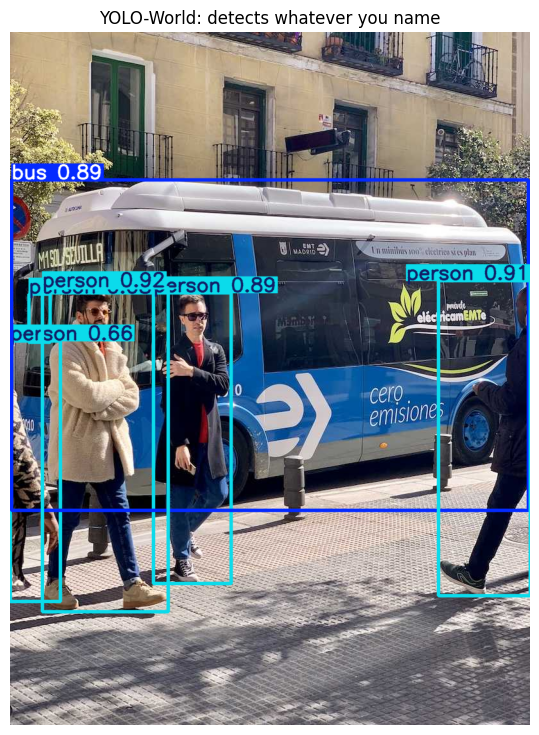

Detected: ['person', 'person', 'bus', 'person', 'person', 'person']


In [16]:
!pip install -q ultralytics
from ultralytics import YOLOWorld

yolo = YOLOWorld("yolov8s-worldv2.pt")     # small, fast, downloads once

# Define your vocabulary on the fly - any words you like.
yolo.set_classes(["bus", "person", "backpack", "traffic light"])

street = load_image("https://ultralytics.com/images/bus.jpg")
res = yolo.predict(street, conf=0.05, verbose=False)

annotated = res[0].plot()                  # returns a BGR image
plt.figure(figsize=(7, 9))
plt.imshow(annotated[:, :, ::-1]); plt.axis("off")
plt.title("YOLO-World: detects whatever you name"); plt.show()

print("Detected:", [yolo.names[int(c)] for c in res[0].boxes.cls])

In [17]:
free_memory(yolo)

Memory freed.


## 4. Depth Anything V2 - 3D geometry from a single photo

**What it's for.** Estimating depth normally needs stereo cameras or LiDAR.
**Depth Anything V2** predicts a dense depth map from **one ordinary image** -
a foundation model for monocular depth that transfers across indoor/outdoor scenes.


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

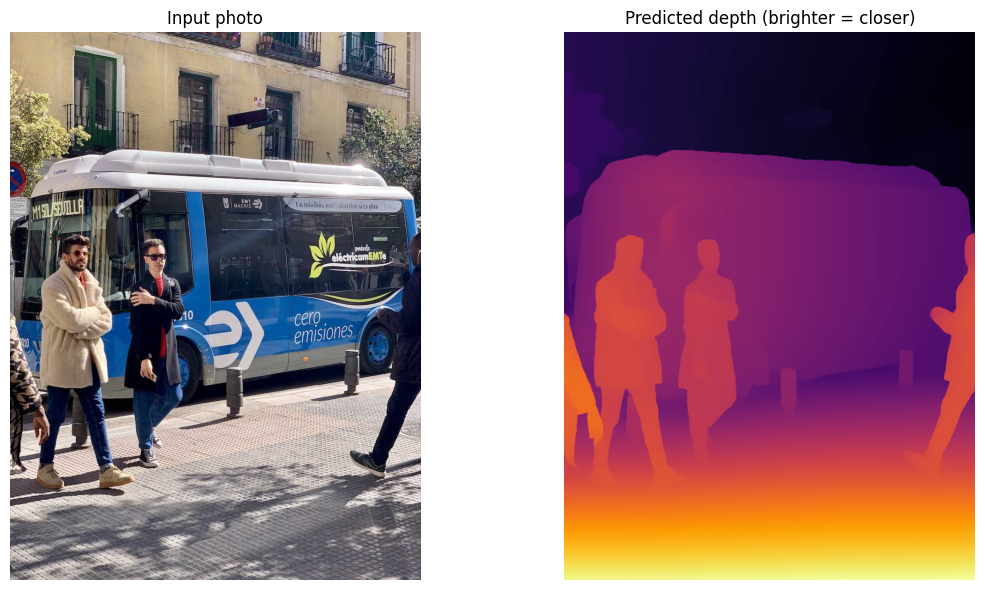

In [18]:
from transformers import pipeline

depth_pipe = pipeline(
    "depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if device == "cuda" else -1,
)

scene = load_image("https://ultralytics.com/images/bus.jpg")
depth = depth_pipe(scene)["depth"]         # a PIL image

fig, (a, b) = plt.subplots(1, 2, figsize=(12, 6))
a.imshow(scene); a.set_title("Input photo"); a.axis("off")
b.imshow(np.array(depth), cmap="inferno")
b.set_title("Predicted depth (brighter = closer)"); b.axis("off")
plt.tight_layout(); plt.show()

In [19]:
free_memory(depth_pipe)

Memory freed.


## 5. Florence-2 - one model, *many* vision tasks (prompt-switched)

**What it's for.** This is a foundation model in the purest sense: a single 0.23B
model that does **captioning, object detection, OCR, segmentation, and grounding** -
you switch tasks by changing a **text tag** (`<CAPTION>`, `<OD>`, `<OCR>`, ...).

In [3]:
!pip install -q einops transformers==4.47.1
from unittest.mock import patch
import torch
from transformers.dynamic_module_utils import get_imports
from transformers import AutoProcessor, AutoModelForCausalLM
device = "cuda"

# Florence-2's remote code lists flash_attn as a requirement even when it's unused
# on a T4. This patch removes that false dependency so the model loads cleanly.
def fixed_get_imports(filename):
    imports = get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

FLOR_ID = "microsoft/Florence-2-base"
with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
    flor = AutoModelForCausalLM.from_pretrained(
        FLOR_ID, trust_remote_code=True, torch_dtype=torch.float16
    ).to(device).eval()
flor_proc = AutoProcessor.from_pretrained(FLOR_ID, trust_remote_code=True)


def run_florence(task, text_input="", img=None):
    img = img if img is not None else image
    prompt = task + text_input
    inp = flor_proc(text=prompt, images=img, return_tensors="pt").to(device, torch.float16)
    ids = flor.generate(
        input_ids=inp["input_ids"], pixel_values=inp["pixel_values"],
        max_new_tokens=1024, do_sample=False,
    )
    txt = flor_proc.batch_decode(ids, skip_special_tokens=False)[0]
    return flor_proc.post_process_generation(txt, task=task, image_size=(img.width, img.height))

print("SAME model, three different tasks - just by changing the tag:\n")
print("<CAPTION>          ->", run_florence("<CAPTION>")["<CAPTION>"])
print("<DETAILED_CAPTION> ->", run_florence("<DETAILED_CAPTION>")["<DETAILED_CAPTION>"])

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


configuration_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

SAME model, three different tasks - just by changing the tag:

<CAPTION>          -> Two cats laying on a pink couch next to a remote control.
<DETAILED_CAPTION> -> The image shows two cats laying on top of a pink blanket on a red couch, with two remotes beside them.


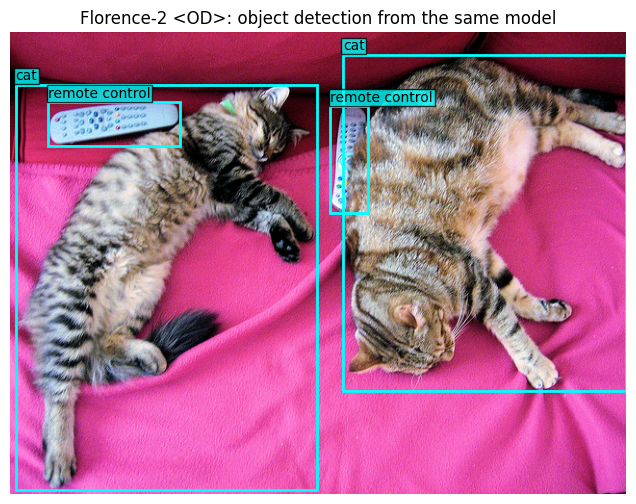

Tip: try run_florence('<OCR>') on an image with text, or '<MORE_DETAILED_CAPTION>'.


In [4]:
import matplotlib.patches as patches

# Now switch the SAME model to object detection with the <OD> tag.
od = run_florence("<OD>")["<OD>"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image); ax.set_title("Florence-2 <OD>: object detection from the same model")
ax.axis("off")
for box, label in zip(od["bboxes"], od["labels"]):
    x0, y0, x1, y1 = box
    ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                   fill=False, edgecolor="cyan", linewidth=2))
    ax.text(x0, y0 - 5, label, color="black", fontsize=10,
            bbox=dict(facecolor="cyan", alpha=0.8, pad=1))
plt.show()
print("Tip: try run_florence('<OCR>') on an image with text, or '<MORE_DETAILED_CAPTION>'.")

In [5]:
free_memory(flor, flor_proc)

Memory freed.


## Exercise: open-vocabulary detection with OWLv2

You've seen open-vocabulary detection (Grounding DINO, YOLO-World). Now wire one up
yourself with **OWLv2** (`https://huggingface.co/google/owlv2-base-patch16-ensemble`).


#### Contributed by: Mohamed Eltayeb